In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import matplotlib.pyplot as plt

Using mask: upstream_mask_r23.tif
Found CHIRPS files: 1
Mask pixels (upstream area): 12038

--- Loading CHIRPS_Brahmaputra_1990.tif (year 1990) ---
  CRS: EPSG:4326
  Transform: | 0.05, 0.00, 73.35|
| 0.00,-0.05, 31.50|
| 0.00, 0.00, 1.00|
  shape (bands, y, x): (365, 181, 489)

Combined precip DataArray (masked to upstream area):
<xarray.DataArray 'precip' (time: 365, y: 181, x: 489)> Size: 129MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., 

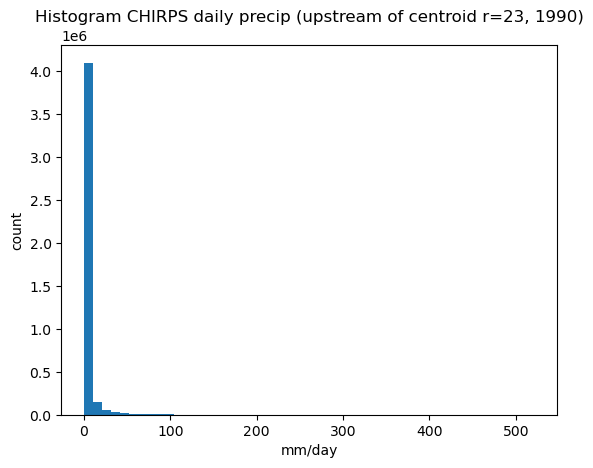

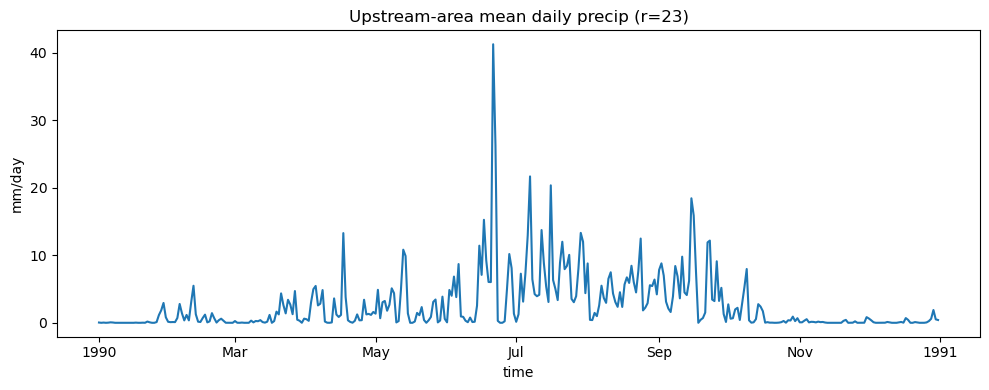

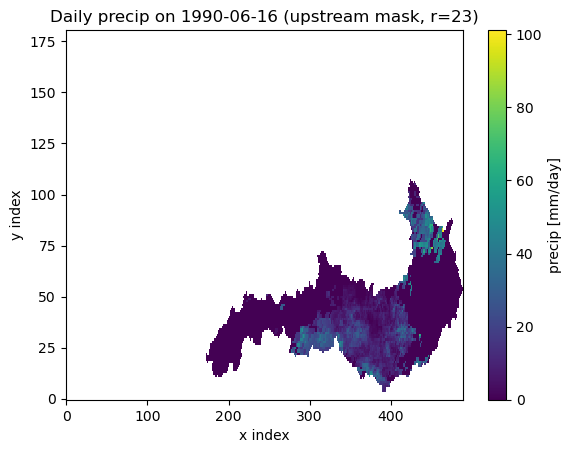


QC5: time series at an in-mask pixel (y=41, x=337), r=23:
<xarray.DataArray 'precip' (time: 5)> Size: 20B
array([0., 0., 0., 0., 0.], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 40B 1990-01-01 1990-01-02 ... 1990-01-05
    y        int64 8B 41
    x        int64 8B 337
Attributes:
    units:       mm/day
    year:        1990
    centroid_r:  23
Number of NaNs at that pixel: 0

QC6: valid pixel count per day (within upstream mask):
  min: 12038 max: 12038


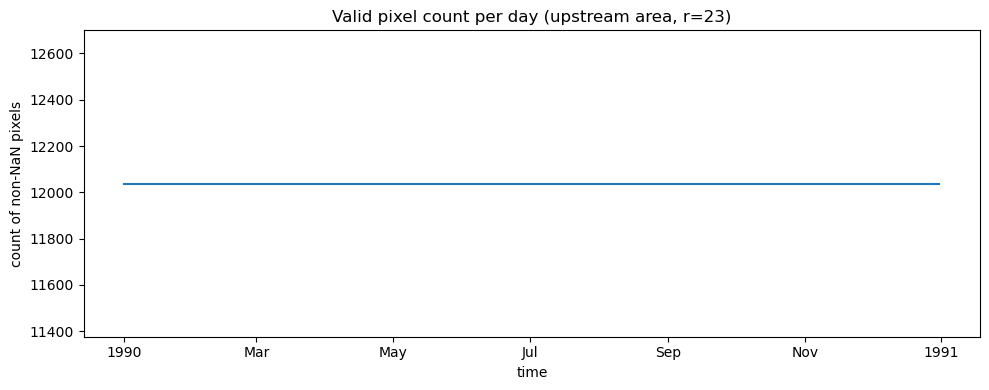


QC7: fraction of valid days per pixel (entire grid; outside mask will be 0):
  min: 0.0 max: 1.0


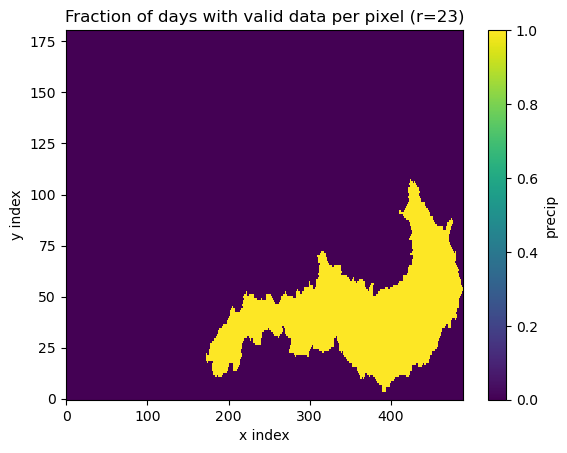

In [9]:
# ==========================================================
# USER SETTINGS
# ==========================================================
DATA_DIR = Path(r"C:\Users\SID-DRW\Downloads\precip_tifs")          # CHIRPS_Brahmaputra_YYYY.tif folder
MASK_DIR = Path(r"C:\Users\SID-DRW\Downloads\upstream_masks")  # folder with upstream_mask_<r>.tif
CENTROID_R = 23   # <-- choose the centroid label 'r' you want to analyze

# Example year window for histogram
HIST_YEAR = 1990
HIST_START = f"{HIST_YEAR}-01-01"
HIST_END   = f"{HIST_YEAR}-12-31"

SAMPLE_DATE = f"{HIST_YEAR}-06-16"  # for spatial map


# ==========================================================
# 1) Find files
# ==========================================================
year_files = sorted(DATA_DIR.glob("CHIRPS_Brahmaputra_*.tif"))
if not year_files:
    raise FileNotFoundError(f"No 'CHIRPS_Brahmaputra_*.tif' in {DATA_DIR}")

mask_path = MASK_DIR / f"upstream_mask_r{CENTROID_R}.tif"
if not mask_path.exists():
    raise FileNotFoundError(f"Mask not found: {mask_path}")

print("Using mask:", mask_path.name)
print("Found CHIRPS files:", len(year_files))


# ==========================================================
# 2) Load mask and verify alignment with first CHIRPS file
# ==========================================================
with rasterio.open(mask_path) as mds:
    mask = mds.read(1).astype(np.uint8)  # 0/1
    mask_transform = mds.transform
    mask_crs = mds.crs
    mask_shape = (mds.height, mds.width)

mask_bool = mask == 1
n_mask_pixels = int(mask_bool.sum())
print("Mask pixels (upstream area):", n_mask_pixels)

if n_mask_pixels == 0:
    raise ValueError("Mask contains zero upstream pixels. Check the upstream ID list / mask creation.")


# ==========================================================
# 3) Load CHIRPS yearly stacks into xarray and apply mask
# ==========================================================
year_das = []

# Use the mask to set non-upstream pixels to NaN in all bands
for tif in year_files:
    year = int(tif.stem.split("_")[-1])  # ..._YYYY.tif
    print(f"\n--- Loading {tif.name} (year {year}) ---")

    with rasterio.open(tif) as ds:
        # Basic alignment checks
        if (ds.height, ds.width) != mask_shape:
            raise ValueError(
                f"Shape mismatch: CHIRPS {ds.height, ds.width} vs mask {mask_shape} "
                f"for file {tif.name}"
            )
        if ds.crs != mask_crs:
            raise ValueError(f"CRS mismatch: CHIRPS {ds.crs} vs mask {mask_crs}")
        if ds.transform != mask_transform:
            # If this triggers, your grids are not identical. Stop here and fix alignment.
            raise ValueError(f"Transform mismatch between CHIRPS and mask for {tif.name}")

        print("  CRS:", ds.crs)
        print("  Transform:", ds.transform)
        print("  shape (bands, y, x):", (ds.count, ds.height, ds.width))

        data = ds.read(masked=True).filled(np.nan)  # (bands, y, x) float with NaNs
        band_names = ds.descriptions
        time = pd.to_datetime(list(band_names), format="%Y%m%d")

    # Apply upstream mask: set everything outside to NaN
    # mask_bool is (y, x), data is (time, y, x) after rename
    data[:, ~mask_bool] = np.nan

    da_year = xr.DataArray(
        data,
        dims=("time", "y", "x"),
        coords={"time": time, "y": np.arange(mask_shape[0]), "x": np.arange(mask_shape[1])},
        name="precip",
        attrs={"units": "mm/day", "year": year, "centroid_r": CENTROID_R},
    )

    year_das.append(da_year)

precip = xr.concat(year_das, dim="time").sortby("time")
print("\nCombined precip DataArray (masked to upstream area):")
print(precip)


# ==========================================================
# 4) QC / plots for this centroid upstream area
# ==========================================================

# QC 1: non-physical values check (first 10 days)
print("\nQC1: non-physical values check (first 10 days):")
subset = precip.isel(time=slice(0, 10))
print("  min:", float(subset.min()), "max:", float(subset.max()))
print("  any negative?:", bool((subset < 0).any()))

# QC 2: histogram for one year range
year_slice = precip.sel(time=slice(HIST_START, HIST_END))
print(f"\nQC2: histogram slice {HIST_START} to {HIST_END}")
print("  valid count:", int(year_slice.notnull().sum().values))

plt.figure()
# Flatten to 1D numeric array for reliability
vals = year_slice.values.ravel()
vals = vals[np.isfinite(vals)]
plt.hist(vals, bins=50)
plt.title(f"Histogram CHIRPS daily precip (upstream of centroid r={CENTROID_R}, {HIST_YEAR})")
plt.xlabel("mm/day")
plt.ylabel("count")
plt.show()

# QC 3: upstream-area mean daily time series
ts_mean = precip.mean(dim=("y", "x"), skipna=True)
plt.figure(figsize=(10, 4))
ts_mean.plot()
plt.title(f"Upstream-area mean daily precip (r={CENTROID_R})")
plt.ylabel("mm/day")
plt.tight_layout()
plt.show()

# QC 4: spatial field for a sample date (masked)
if SAMPLE_DATE in precip.time.dt.strftime("%Y-%m-%d").values:
    da_day = precip.sel(time=SAMPLE_DATE)
    plt.figure()
    da_day.plot()
    plt.title(f"Daily precip on {SAMPLE_DATE} (upstream mask, r={CENTROID_R})")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.show()
else:
    print(f"QC4: {SAMPLE_DATE} not found in time coordinate")

# QC 5: time series at one pixel (choose a pixel that is inside mask)
ys, xs = np.where(mask_bool)
y_idx, x_idx = int(ys[len(ys)//2]), int(xs[len(xs)//2])  # a guaranteed-in-mask pixel
ts_pixel = precip.isel(y=y_idx, x=x_idx)
print(f"\nQC5: time series at an in-mask pixel (y={y_idx}, x={x_idx}), r={CENTROID_R}:")
print(ts_pixel.head())

num_nans = int(ts_pixel.isnull().sum())
print(f"Number of NaNs at that pixel: {num_nans}")

# QC 6: mask stability — number of valid pixels per day (in upstream area)
valid_per_day = precip.notnull().sum(dim=("y", "x"))
print("\nQC6: valid pixel count per day (within upstream mask):")
print("  min:", int(valid_per_day.min().values),
      "max:", int(valid_per_day.max().values))

plt.figure(figsize=(10, 4))
valid_per_day.plot()
plt.title(f"Valid pixel count per day (upstream area, r={CENTROID_R})")
plt.ylabel("count of non-NaN pixels")
plt.tight_layout()
plt.show()

# QC 7: fraction of valid days per pixel (within upstream area)
valid_days_per_pixel = precip.notnull().sum(dim="time")
total_days = precip.sizes["time"]
fraction_valid = valid_days_per_pixel / total_days

print("\nQC7: fraction of valid days per pixel (entire grid; outside mask will be 0):")
print("  min:", float(fraction_valid.min()), "max:", float(fraction_valid.max()))

plt.figure()
fraction_valid.plot()
plt.title(f"Fraction of days with valid data per pixel (r={CENTROID_R})")
plt.xlabel("x index")
plt.ylabel("y index")
plt.show()
